# Fig 3a — Classification heatmap by model group

Patient-level classification on the **7 shared tasks** (CV folds, Random Forest head). Finetuned Geneformer, PCA [100], and PCA [50] are excluded.

**Layout:** models are grouped (`Baseline → Geneformer → Other → scGPT`). Within each group, models are ranked by **macro-mean** of the plotted metric (mean of per-task means, so each task has equal weight even when fold counts differ). Tasks (rows) are ranked by mean across models.

Data: `results/classification.metrics.csv`


In [1]:
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'results' / 'classification.metrics.csv').exists():
            return candidate
    fallback = Path.home() / 'scFM_eval'
    if (fallback / 'results' / 'classification.metrics.csv').exists():
        return fallback
    raise FileNotFoundError('Could not find results/classification.metrics.csv')


REPO_ROOT = _repo_root()
METRICS_PATH = REPO_ROOT / 'results' / 'classification.metrics.csv'
PLOTS_DIR = Path('./plots')
if not Path('Fig3_a_v8.ipynb').exists() and (REPO_ROOT / 'analysis' / 'classification').exists():
    PLOTS_DIR = REPO_ROOT / 'analysis' / 'classification' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

METRICS = ['AUPRC', 'AUC', 'F1', 'Recall', 'Precision', 'Accuracy']
STRATEGIES = ['MIL', 'vote', 'avg']
# Intended panel order. Do not rely on alphabetical `group` strings.
GROUP_ORDER = ['Baseline', 'Geneformer', 'Other', 'scGPT']
EXCLUDE_NAME_CONTAINS = ['finetune', 'continue']
EXCLUDE_MODEL_NAMES = ['PCA [100]', 'PCA [50]']


## Sorting

`process_and_sort` previously ranked models with:

```python
sort_values(by=['group', 'mean_overall'], ascending=[True, False])
```

That only produces `Baseline → Geneformer → Other → scGPT` because those names happen to sort alphabetically. A new group (or a rename) would land in the wrong panel. The plot then did `groupby('group')` with the default `sort=True`, which **re-alphabetizes groups** and can also scramble a custom order.

Fixes:
- encode `group` as an ordered categorical (`GROUP_ORDER`)
- stable sort, then `reset_index`
- iterate with `groupby(..., sort=False, observed=True)` so panel order matches `sorted_models`
- pivot with `pivot_table` + `reindex` so duplicate (task, model) rows cannot break column order


In [2]:
def summarize_task_means(fold_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Average CV folds first so each task contributes equally to the model ranking."""
    if metric not in fold_df.columns:
        raise KeyError(f'{metric} not in columns: {list(fold_df.columns)}')

    task_means = (
        fold_df
        .groupby(['exp_display', 'model_display', 'group'], as_index=False)[metric]
        .mean()
        .rename(columns={
            metric: 'mean',
            'exp_display': 'experiment_name',
            'model_display': 'experiment',
        })
    )
    return task_means


def process_and_sort(
    df: pd.DataFrame,
    group_order: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (task × model heatmap, model table sorted for plotting).

    Model order: `GROUP_ORDER`, then macro-mean of `mean` descending within each group.
    """
    group_order = group_order or GROUP_ORDER
    required = {'experiment', 'experiment_name', 'group', 'mean'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'process_and_sort missing columns: {sorted(missing)}')

    groups_per_model = df.groupby('experiment')['group'].nunique()
    if (groups_per_model > 1).any():
        bad = groups_per_model[groups_per_model > 1].index.tolist()
        raise ValueError(f'model(s) assigned to multiple groups: {bad}')

    model_means = (
        df.groupby('experiment', as_index=False)
        .agg(mean_overall=('mean', 'mean'))
    )
    model_groups = df[['experiment', 'group']].drop_duplicates()
    sorted_models = model_means.merge(
        model_groups, on='experiment', how='left', validate='one_to_one'
    )

    sorted_models['group'] = pd.Categorical(
        sorted_models['group'], categories=group_order, ordered=True
    )
    unknown = sorted_models['group'].isna()
    if unknown.any():
        bad = sorted_models.loc[unknown, 'experiment'].tolist()
        raise ValueError(f'model(s) have a group outside {group_order}: {bad}')

    # mergesort keeps a deterministic order when macro-means tie
    sorted_models = (
        sorted_models
        .sort_values(['group', 'mean_overall'], ascending=[True, False], kind='mergesort')
        .reset_index(drop=True)
    )

    heatmap_df = df.pivot_table(
        index='experiment_name',
        columns='experiment',
        values='mean',
        aggfunc='mean',
    )
    heatmap_df = heatmap_df.reindex(columns=sorted_models['experiment'])

    _assert_within_group_descending(sorted_models)
    return heatmap_df, sorted_models


def _assert_within_group_descending(sorted_models: pd.DataFrame) -> None:
    for group_name, group_df in sorted_models.groupby('group', sort=False, observed=True):
        vals = group_df['mean_overall'].to_numpy()
        if len(vals) > 1 and not np.all(vals[:-1] >= vals[1:] - 1e-12):
            raise AssertionError(
                f'{group_name} is not sorted by mean_overall descending:\n'
                f"{group_df[['experiment', 'mean_overall']].to_string(index=False)}"
            )


def plot_composite_by_group_panels(
    heatmap_df: pd.DataFrame,
    sorted_models: pd.DataFrame,
    metric: str,
    clf: str = 'MIL',
    save_dir: Path | str = '.',
    close: bool = True,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    display_models = sorted_models.copy()
    display_models['mean_overall'] = display_models['mean_overall'].round(2)
    heatmap_df = heatmap_df.round(2)

    row_avg = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.loc[row_avg.sort_values(ascending=False).index]

    # sort=False: keep GROUP_ORDER from process_and_sort (default groupby re-alphabetizes)
    grouped = display_models.groupby('group', sort=False, observed=True)
    group_items = list(grouped)
    n_groups = len(group_items)
    palette = sns.color_palette('husl', n_groups)
    color_map = {name: palette[i] for i, (name, _) in enumerate(group_items)}

    global_vmin = float(heatmap_df.min().min())
    global_vmax = float(heatmap_df.max().max())
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    cmap = plt.colormaps['viridis']

    group_model_counts = [len(group_df) for _, group_df in group_items]
    total_models = sum(group_model_counts)
    fig = plt.figure(figsize=(max(6, total_models * 0.5 + 1.5), max(6, heatmap_df.shape[0] * 0.6)))
    gs = gridspec.GridSpec(
        3,
        n_groups + 2,
        width_ratios=group_model_counts + [1.0, 0.2],
        height_ratios=[1.2, 6, 0.4],
        hspace=0.3,
        wspace=0.1,
    )

    cbar_ax = None
    for i, (group_name, group_df) in enumerate(group_items):
        show_cbar = i == n_groups - 1
        if show_cbar:
            cbar_ax = fig.add_subplot(gs[1, -1])

        color = color_map[group_name]
        model_names = group_df['experiment'].tolist()
        model_avg = group_df['mean_overall'].tolist()
        group_heatmap = heatmap_df[model_names]

        ax_top = fig.add_subplot(gs[0, i])
        bars = ax_top.bar(range(len(model_avg)), model_avg, color=color)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        ymin = min(0.7, max(0.0, min(model_avg) - 0.05)) if model_avg else 0.7
        ax_top.set_ylim(ymin, 1.0)
        for spine in ax_top.spines.values():
            spine.set_visible(False)
        for bar in bars:
            height = bar.get_height()
            ax_top.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=6,
            )

        ax_heatmap = fig.add_subplot(gs[1, i])
        sns.heatmap(
            group_heatmap,
            ax=ax_heatmap,
            annot=False,
            fmt='.2f',
            cmap='viridis',
            vmin=global_vmin,
            vmax=global_vmax,
            cbar=show_cbar,
            cbar_ax=cbar_ax,
            xticklabels=False,
            annot_kws={'size': 6},
        )
        ax_heatmap.set_xticklabels([])
        ax_heatmap.tick_params(axis='x', bottom=False)
        ax_heatmap.set_xlabel(group_name)
        ax_heatmap.set_ylabel('')
        if i != 0:
            ax_heatmap.set_yticks([])
            ax_heatmap.set_yticklabels([])

        ax_bottom = fig.add_subplot(gs[2, i])
        for j in range(len(model_names)):
            ax_bottom.add_patch(plt.Rectangle((j, 0), 1, 1, color=color))
        ax_bottom.set_xlim(0, len(model_names))
        ax_bottom.set_ylim(0, 1)
        ax_bottom.axis('off')
        for j, model in enumerate(model_names):
            ax_bottom.text(
                j + 0.5, -0.2, model,
                ha='right', va='top', rotation=90, fontsize=10, rotation_mode='anchor',
            )

    ax_right_bar = fig.add_subplot(gs[1, -2])
    avg_vals = heatmap_df.mean(axis=1)
    y_positions = np.arange(len(avg_vals))
    colors = [cmap(norm(val)) for val in avg_vals]
    ax_right_bar.barh(y_positions, avg_vals.values, color=colors)
    ax_right_bar.invert_yaxis()
    ax_right_bar.set_xlim(0.4, 1.0)
    ax_right_bar.set_yticks([])
    ax_right_bar.set_xticks([])
    ax_right_bar.set_xlabel(f'Avg {metric}', fontsize=5)
    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)

    if cbar_ax is not None:
        cbar_ax.tick_params(labelsize=6)

    fig.subplots_adjust(bottom=0.25)
    output_path = save_dir / f'{metric}_{clf}.png'
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    print(f'Grouped panel heatmap saved to {output_path}')
    if close:
        plt.close(fig)
    return fig


## Load metrics


In [3]:
raw = pd.read_csv(METRICS_PATH)

exclude_unmapped = raw['model_display'].isna() | raw['exp_display'].isna()
name = raw['model_display'].fillna('')
exclude_by_substring = pd.Series(False, index=raw.index)
for needle in EXCLUDE_NAME_CONTAINS:
    exclude_by_substring |= name.str.contains(needle, case=False, regex=False)
exclude_by_name = name.isin(EXCLUDE_MODEL_NAMES)
exclude = exclude_unmapped | exclude_by_substring | exclude_by_name

df = raw.loc[~exclude].copy()
dropped_models = sorted(raw.loc[exclude & ~exclude_unmapped, 'model_display'].dropna().unique())

print(
    f'{df["model_display"].nunique()} models, '
    f'{df["exp_display"].nunique()} tasks, '
    f'{len(df)} fold rows '
    f'(dropped {int(exclude_unmapped.sum())} unmapped rows, '
    f'{int((exclude_by_substring | exclude_by_name).sum())} rows from {dropped_models})'
)
print('strategies:', list(df['strategy'].unique()))
print('classifiers:', list(df['classifier'].unique()))
df.head()


15 models, 7 tasks, 1530 fold rows (dropped 0 unmapped rows, 272 rows from ['GF-V1 [finetune]', 'GF-V2 [finetune]', 'PCA [100]', 'PCA [50]'])
strategies: ['vote', 'MIL', 'avg']
classifiers: ['randomforest']


,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,exp_path,strategy,classifier,metrics_path,group,model_display,exp_display
0,0.571429,0.250000,0.875000,0.466667,0.437500,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
1,0.916667,0.833333,0.750000,0.428571,0.375000,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
2,0.833333,0.750000,0.750000,0.428571,0.375000,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
3,0.583333,0.366667,0.750000,0.428571,0.375000,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
4,0.000000,0.142857,0.857143,0.461538,0.428571,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v8/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo


## Main panel — AUPRC, MIL

Frozen embeddings with a Random Forest head. Finetune / PCA [100] / PCA [50] are filtered out above.


In [4]:
METRIC = 'AUPRC'
STRATEGY = 'MIL'

fold_df = df[df['strategy'] == STRATEGY].copy()
task_df = summarize_task_means(fold_df, METRIC)
heatmap_df, sorted_models = process_and_sort(task_df)

print('Model order (group, then macro-mean AUPRC descending):')
display(sorted_models)
heatmap_df


Model order (group, then macro-mean AUPRC descending):


,experiment,mean_overall,group
0,HVG,0.901709,Baseline
1,scVI,0.901320,Baseline
2,PCA [20],0.890854,Baseline
3,GF-V2 [cancer],0.904798,Geneformer
4,GF-V2,0.897872,Geneformer
5,GF-V2-Deep,0.864107,Geneformer
6,GF-V1,0.851899,Geneformer
7,SCimiarity,0.937055,Other
8,STATE,0.916947,Other
9,scConcept,0.892238,Other


experiment,HVG,scVI,PCA [20],GF-V2 [cancer],GF-V2,GF-V2-Deep,GF-V1,SCimiarity,STATE,scConcept,scFoundation,Nicheformer,CellPLM,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,,,,,,
ER+ vs TNBC,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.983333,1.000000,1.000000,0.983333,1.000000,0.983333,1.000000,0.966667,0.983333
IO Response,0.916667,0.900000,0.816667,0.933333,0.950000,0.933333,0.833333,0.966667,0.866667,0.950000,0.950000,0.866667,1.000000,0.916667,0.883333
MMRd vs MMRp,0.891960,0.869238,0.850737,0.930889,0.828436,0.918746,0.802563,0.819706,0.935293,0.815110,0.825007,0.834833,0.777419,0.572276,0.592944
T-cell exhaustion,0.916667,0.866667,0.840000,0.883333,0.833333,0.696667,0.833333,0.790000,0.900000,0.783333,0.840000,0.806667,0.873333,0.640000,0.723333
Treatment Naive vs Anti PD1,1.000000,1.000000,1.000000,0.984127,1.000000,1.000000,0.907394,0.983016,1.000000,0.947222,1.000000,1.000000,0.889372,0.844246,0.656944
Treatment Naive vs Neoadjuvant Chemo,0.586667,0.673333,0.728571,0.601905,0.673333,0.500000,0.603333,1.000000,0.716667,0.766667,0.506667,0.580000,0.448333,0.560714,0.568571
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/AUPRC_MIL.png


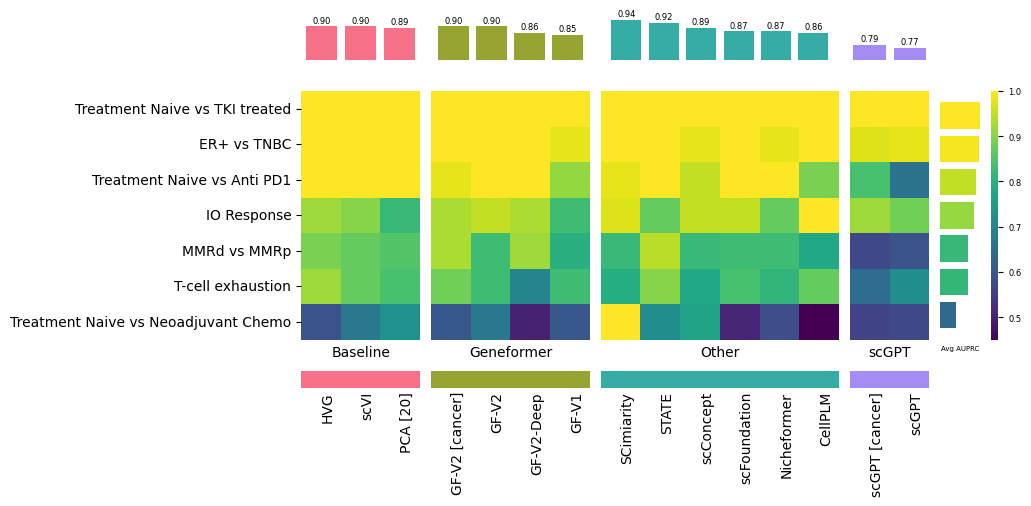

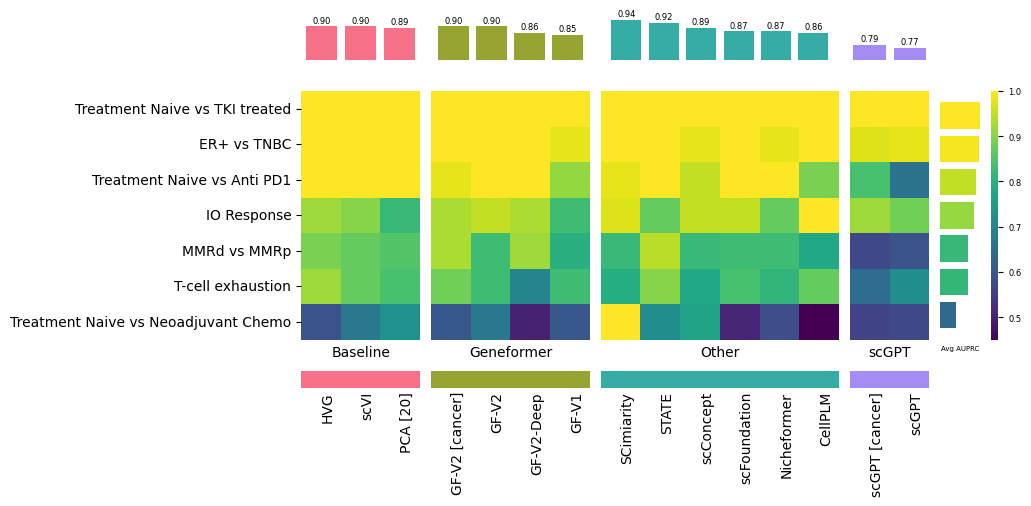

In [5]:
fig = plot_composite_by_group_panels(
    heatmap_df, sorted_models, METRIC, clf=STRATEGY, save_dir=PLOTS_DIR, close=False
)
fig


## Other metrics and aggregation strategies

Same model filter as the main panel, for every metric × strategy.


In [6]:
for strategy in STRATEGIES:
    for metric in METRICS:
        fold_df = df[df['strategy'] == strategy]
        if fold_df.empty:
            print(f'skip {strategy} / {metric}: no rows')
            continue
        task_df = summarize_task_means(fold_df, metric)
        
        heatmap_i, sorted_i = process_and_sort(task_df)
        plot_composite_by_group_panels(
            heatmap_i, sorted_i, metric, clf=strategy, save_dir=PLOTS_DIR, close=True
        )


Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/AUPRC_MIL.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/AUC_MIL.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/F1_MIL.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/Recall_MIL.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/Precision_MIL.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/Accuracy_MIL.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/AUPRC_vote.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/AUC_vote.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/F1_vote.png
Grouped panel heatmap saved to /home/haitham/scFM_eval/analysis/classification/plots/Recall_vote.png
Grouped